### Reading Resutls

In [91]:
import os
import glob
import pandas as pd

# 1. Smarter path finding (Fixed to point to M=2000 for both paths!)
folder_path = "simulations/results/M=2000"
if not os.path.exists(folder_path):
    folder_path = "../results/M=2000"  

# 2. Grab ONLY files that start with "summary_"
file_paths = glob.glob(os.path.join(folder_path, "summary_*.csv"))

# Hard stop if paths are still wrong
if not file_paths:
    raise FileNotFoundError(f"Could not find any CSV files in: {os.path.abspath(folder_path)}")

# 3. Define strictly the columns you want to keep
cols_to_keep = ["Method", "N", "n", "Dm", "Ds", "Vm", "Vs", "Mm", "Ms", "Lm", "Ls"]

all_dfs = []

for file in file_paths:
    # Read the data
    df = pd.read_csv(file)
    
    # Filter out the unwanted columns safely
    df = df[cols_to_keep].copy()
    
    # Extract the population name from the filename
    filename = os.path.basename(file)
    pop_name = filename.split('_')[1] 
    
    # Insert the population name as the first column
    df.insert(0, 'Population', pop_name)
    
    all_dfs.append(df)

# 4. Combine everything into one clean master DataFrame
master_summary = pd.concat(all_dfs, ignore_index=True)

# 5. CLIP THE Lm COLUMN BETWEEN -2 AND 2
master_summary['Lm'] = master_summary['Lm'].clip(lower=-1.5, upper=1.5)

print(f"Success! Loaded {len(file_paths)} files.")
display(master_summary.head())

Success! Loaded 12 files.


,Population,Method,N,n,Dm,Ds,Vm,Vs,Mm,Ms,Lm,Ls
0,clust,Lopi,100,10,-0.106243,0.185852,0.189922,0.069750,-0.182196,0.096128,0.436831,0.579086
1,clust,Maxe,100,10,-0.235532,0.318523,0.415877,0.228262,0.043407,0.148042,0.552714,0.633175
2,clust,Rand,100,10,-0.190073,0.271158,0.919553,0.651621,-0.042868,0.120929,1.500000,2.565358
3,clust,Scps,100,10,-0.094831,0.189501,0.184903,0.068995,-0.208786,0.091597,0.422989,0.559248
4,clust,Wave,100,10,-0.104227,0.171581,0.188599,0.068100,-0.318710,0.068483,0.421332,0.512332


In [92]:
color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo (From your "MAX")
    'Lopi': '#7FB685',  # Red (From your "WAV" / what was red in your legend)
    'Scps': '#F6C667',  # Pastel Green (From your "LP1")
    'Wave': '#FF0000',  # Soft Orange (From your "NMS")
}

color_dict = {
    'Maxe': '#6C7CA2',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}


color_dict = {
    'Maxe': '#8D6E63',  # Pastel Indigo
    'Lopi': '#F6C667',  # Pastel Green
    'Scps': '#7FB685',  # Soft Amber
    'Wave': '#FF0000',  # Pure Red
}
    # "Autumn & Earth": ['#FFCA28', '', '', '', '#1E88E5', '#D81B60'],#E65100

# color_dict = {
#     'Maxe': '#5C6B8C',  # Deeper Slate Blue
#     'Lopi': '#6EA174',  # Sage Green
#     'Scps': '#E5B25D',  # Warm Gold
#     'Wave': '#D93838',  # Brick Red
# }

# color_dict = {
#     'Maxe': '#8D6E63',  # Muted Cocoa
#     'Lopi': '#FBC02D',  # Golden Yellow
#     'Scps': '#E65100',  # Burnt Orange
#     'Wave': '#C62828',  # Deep Crimson
# }

# color_dict = {
#     'Maxe': '#424242',  # Dark Charcoal
#     'Lopi': '#9E9E9E',  # Neutral Grey
#     'Scps': '#E0E0E0',  # Light Silver
#     'Wave': '#E53935',  # Striking Red
# }






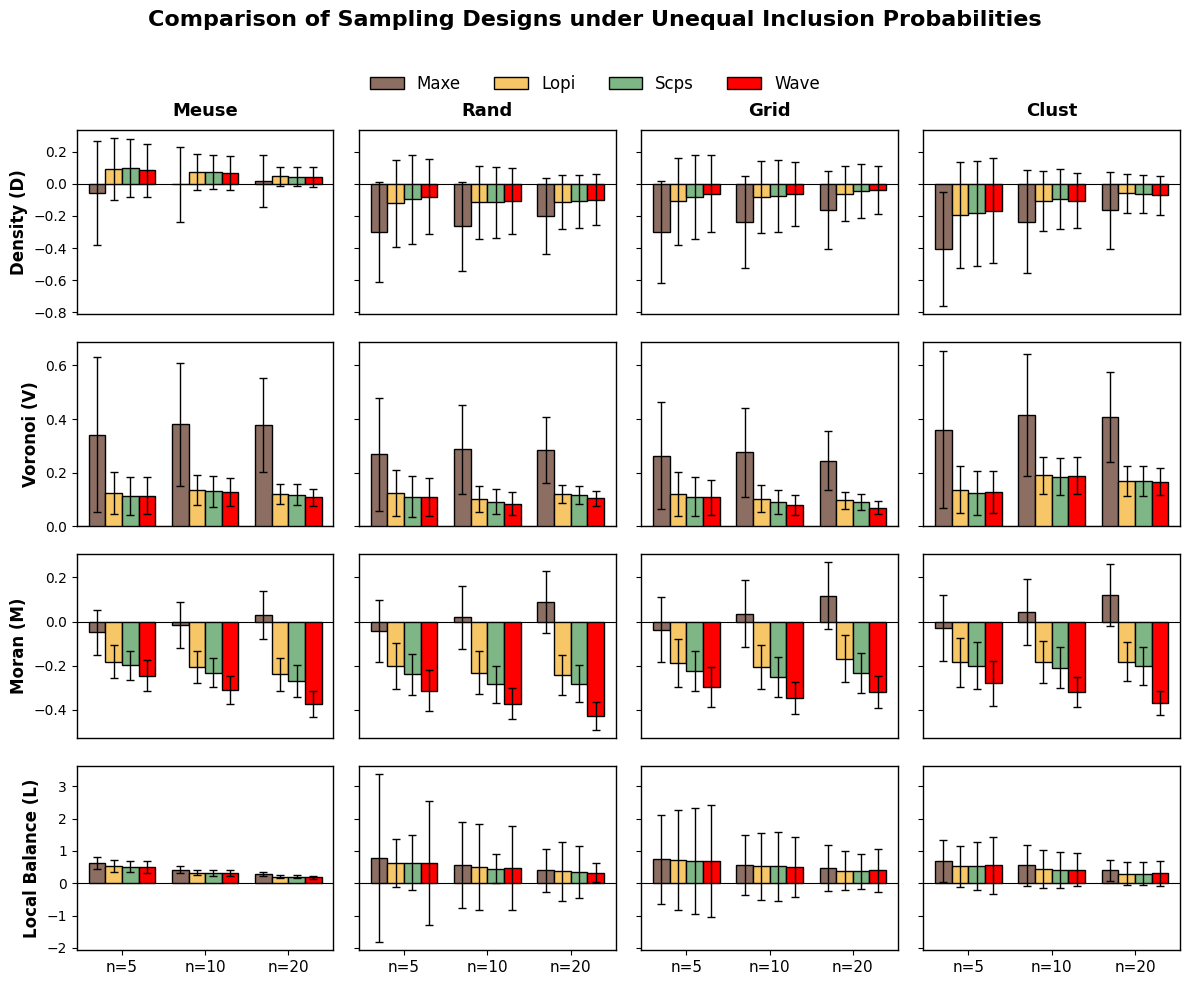

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. USER CONTROLS (Change these lists to reorder!)
# ==========================================

# 🔹 REARRANGE COLUMNS: Change the order of strings in this list to reorder your columns left-to-right
target_populations = ['meuse', 'rand', 'grid', 'clust'] 

# 🔹 REARRANGE ROWS: Change the order of these 4 lines to reorder your metrics top-to-bottom
target_metrics = [
    ('Dm', 'Ds', 'Density (D)'),
    ('Vm', 'Vs', 'Voronoi (V)'),
    ('Mm', 'Ms', 'Moran (M)'),
    ('Lm', 'Ls', 'Local Balance (L)')
]

# ==========================================
# 2. Data Preparation & Colors
# ==========================================

df_plot = master_summary[master_summary['Method'] != 'Rand'].copy()

# Ensure the populations actually exist in the data before plotting
pops = [p for p in target_populations if p in df_plot['Population'].unique()]

# Define Method Ordering
all_methods = df_plot['Method'].unique().tolist()
if 'Maxe' in all_methods:
    all_methods.remove('Maxe')
    methods_order = ['Maxe'] + sorted(all_methods) 
else:
    methods_order = sorted(all_methods)


# ==========================================
# 3. Plotting Engine
# ==========================================

fig, axes = plt.subplots(nrows=len(target_metrics), ncols=len(pops), figsize=(12, 10), sharey='row')

# Add the main overarching title
fig.suptitle("Comparison of Sampling Designs under Unequal Inclusion Probabilities", 
             fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue
            
        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))
        width = 0.8 / len(methods_order) 
        
        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n')
            method_data = method_data.reindex(n_vals) 
            
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            
            offset = (i - len(methods_order)/2 + 0.5) * width
            
            ax.bar(x + offset, means, width, yerr=stds, 
                   label=method if (row_idx == 0 and col_idx == 0) else "", 
                   color=color_dict.get(method, '#888888'), 
                   capsize=3, edgecolor='black', linewidth=1.0, 
                   error_kw={'elinewidth': 1.0, 'capthick': 1.0}, zorder=3)
        
        # --- Formatting for the "Plain Sheet" Look ---
        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold', pad=10)
        
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
            
        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([]) 
            ax.tick_params(axis='x', length=0) 
            
        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        
        # 1. Turn off all inner grid lines
        ax.grid(False) 
        
        # 2. Force the standard box border around the plot to stay visible
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

# Add the master legend
fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), 
           fontsize=12, frameon=False)

plt.tight_layout()
# Adjust top spacing to make room for both the suptitle and the legend
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15) 
plt.show()

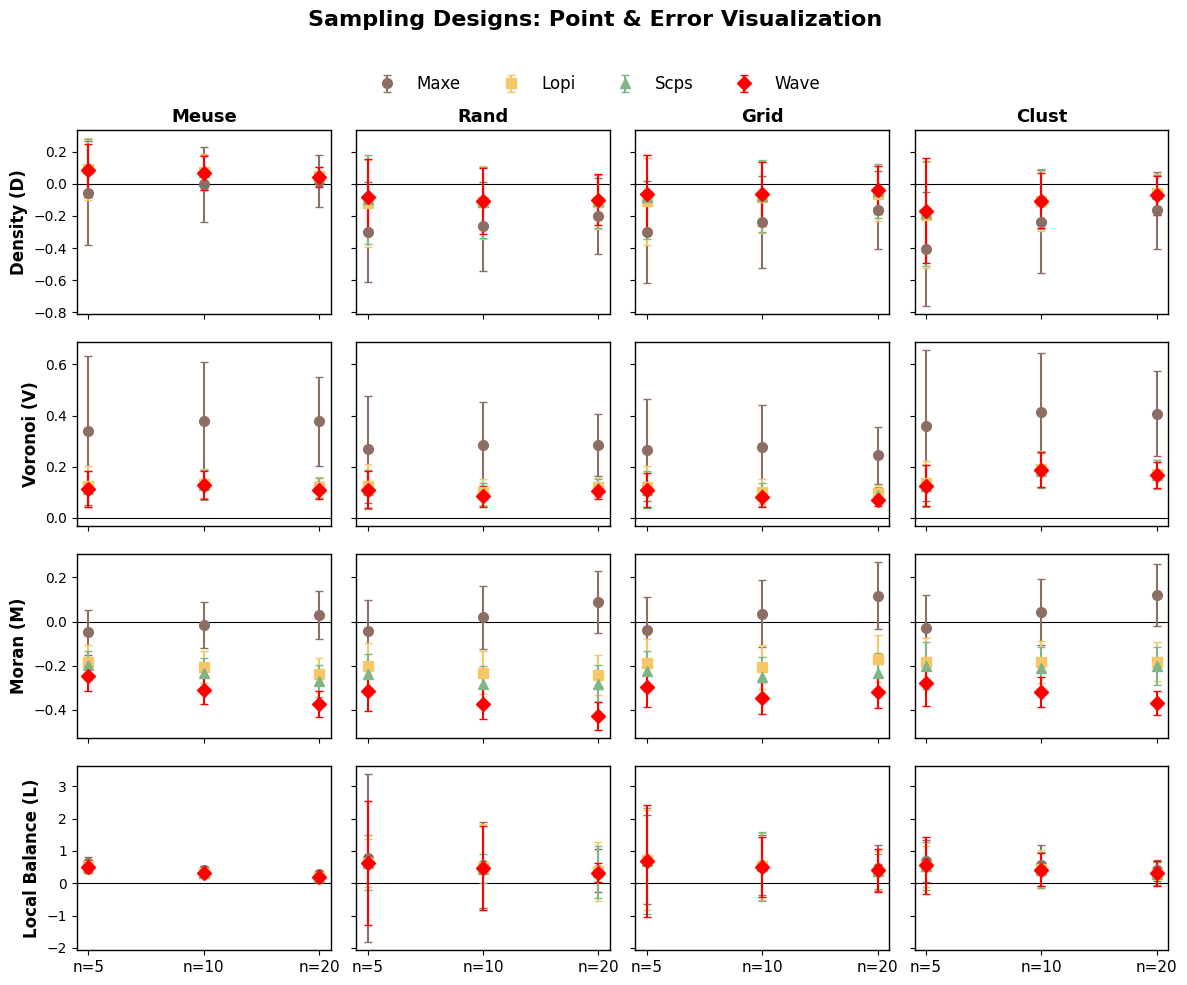

In [95]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Point & Error Visualization", fontsize=16, fontweight='bold', y=0.98)

markers = ['o', 's', '^', 'D', 'P', '*', 'X']  # One per method

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.errorbar(x, means, yerr=stds, fmt=markers[i % len(markers)],
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=7, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

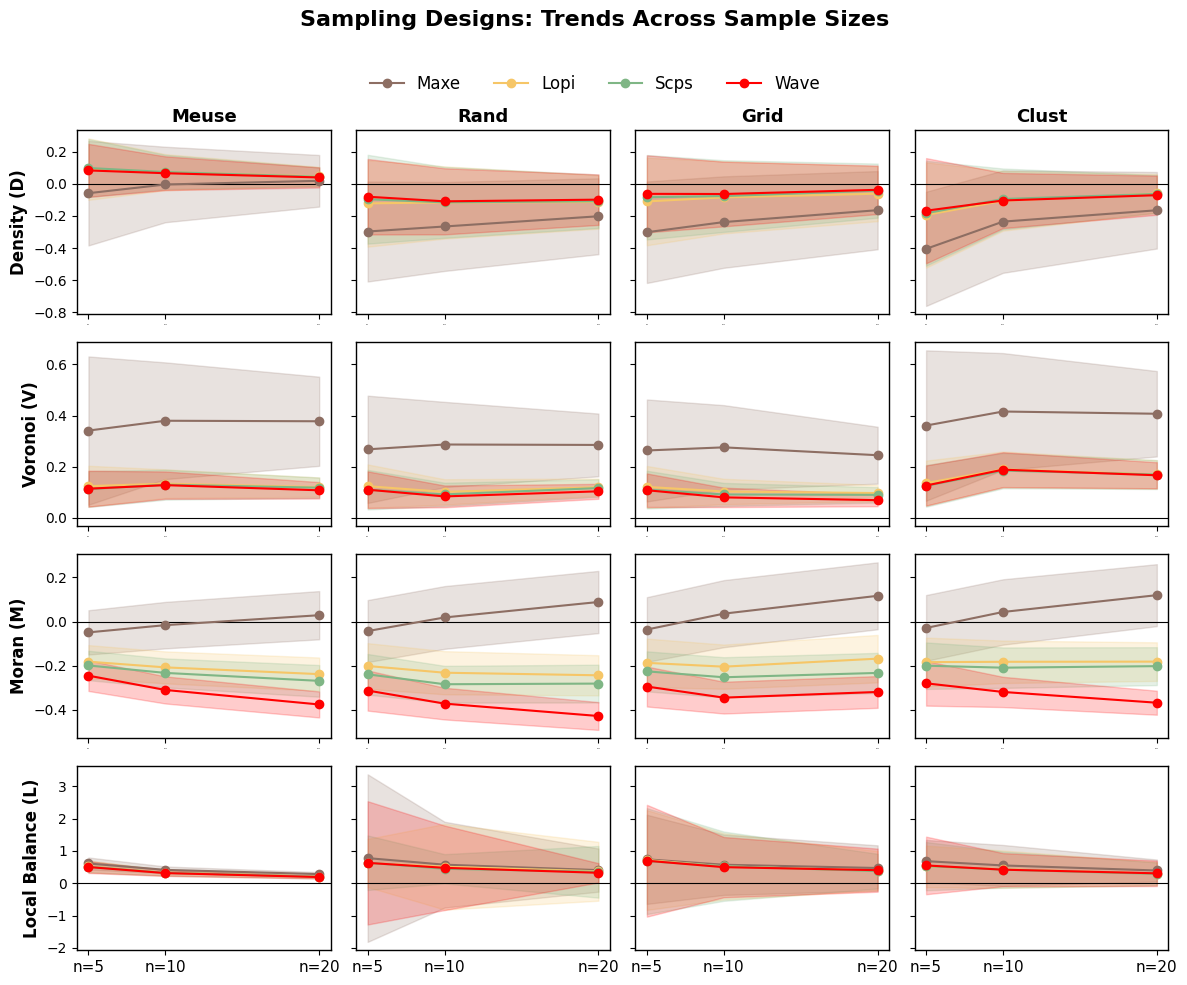

In [96]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Trends Across Sample Sizes", fontsize=16, fontweight='bold', y=0.98)

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            ax.plot(n_vals, means, marker='o', color=color_dict.get(method, '#888888'),
                    label=method if (row_idx == 0 and col_idx == 0) else "", zorder=3)
            ax.fill_between(n_vals, means - stds, means + stds, color=color_dict.get(method, '#888888'), alpha=0.2)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(n_vals)
        ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11 if row_idx == len(target_metrics) - 1 else 0)

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()

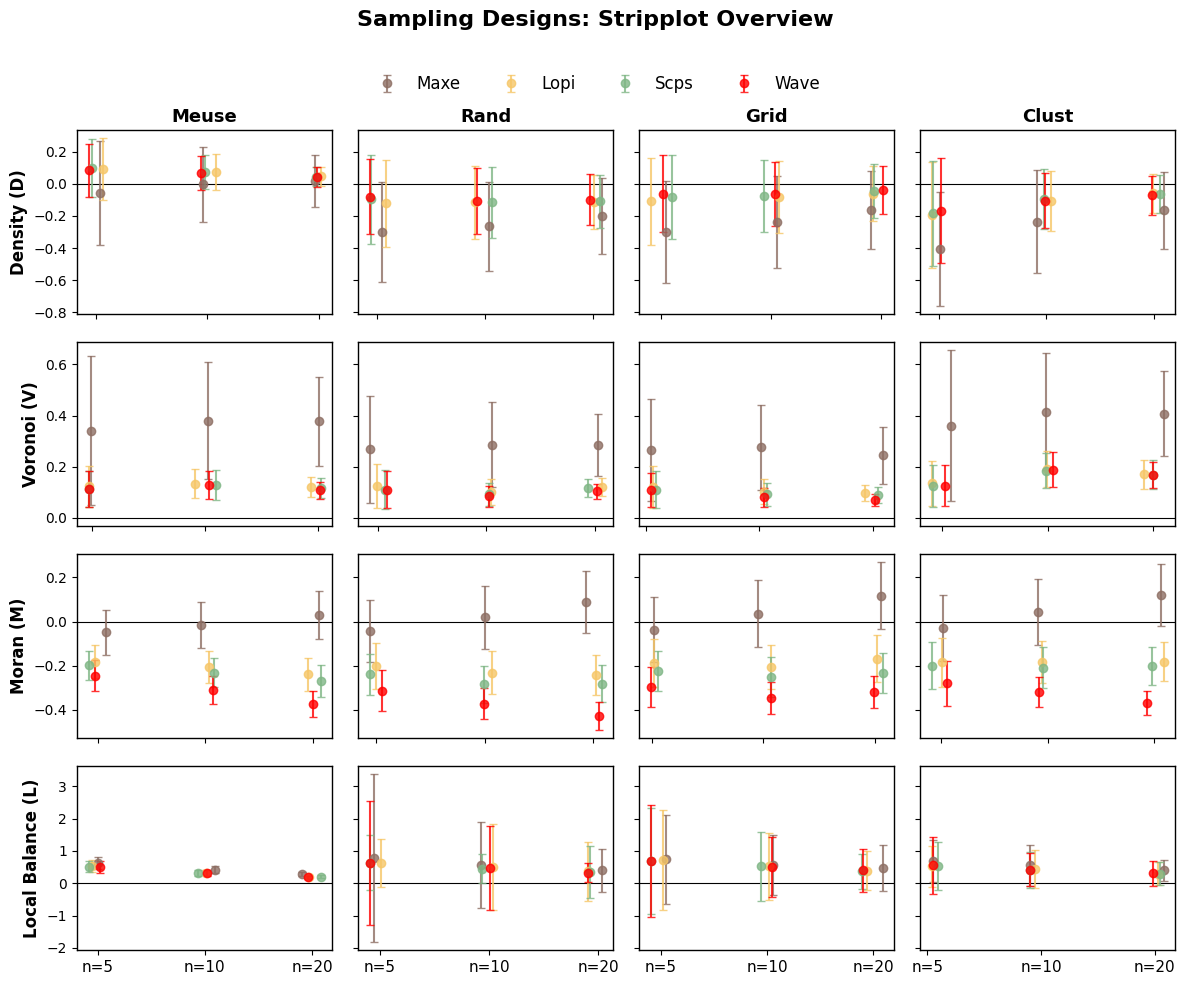

In [97]:
fig, axes = plt.subplots(len(target_metrics), len(pops), figsize=(12, 10), sharey='row')
fig.suptitle("Sampling Designs: Stripplot Overview", fontsize=16, fontweight='bold', y=0.98)

jitter_strength = 0.1

for row_idx, (mean_col, std_col, metric_name) in enumerate(target_metrics):
    for col_idx, pop in enumerate(pops):
        ax = axes[row_idx, col_idx]
        pop_data = df_plot[df_plot['Population'] == pop]
        if pop_data.empty:
            ax.set_visible(False)
            continue

        n_vals = sorted(pop_data['n'].unique())
        x_base = np.arange(len(n_vals))

        for i, method in enumerate(methods_order):
            method_data = pop_data[pop_data['Method'] == method].set_index('n').reindex(n_vals)
            means = method_data[mean_col].values
            stds = method_data[std_col].values
            jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(x_base))
            ax.errorbar(x_base + jitter, means, yerr=stds, fmt='o',
                        color=color_dict.get(method, '#888888'),
                        label=method if (row_idx == 0 and col_idx == 0) else "", capsize=3, markersize=6, alpha=0.8, zorder=3)

        if row_idx == 0:
            ax.set_title(pop.capitalize(), fontsize=13, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(metric_name, fontsize=12, fontweight='bold')
        ax.set_xticks(x_base)
        if row_idx == len(target_metrics) - 1:
            ax.set_xticklabels([f"n={nv}" for nv in n_vals], fontsize=11)
        else:
            ax.set_xticklabels([])

        ax.axhline(0, color='black', linewidth=0.8, zorder=1)
        ax.grid(False)
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)

fig.legend(loc='upper center', bbox_to_anchor=(0.5, 0.93), ncol=len(methods_order), fontsize=12, frameon=False)
plt.tight_layout()
plt.subplots_adjust(top=0.86, wspace=0.10, hspace=0.15)
plt.show()